# 02: Data Intuition - What is "Data" Really?

> ⚠️ **Important:** Run cells in order from top to bottom! In Colab/Jupyter: **Runtime → Run all** (or **Kernel → Restart & Run All**)

## The Big Picture

Machine Learning is about **finding patterns in data**. Before we can find patterns, we need to understand:

1. **What is data?** (Features, labels, samples)
2. **How is it distributed?** (Understanding your data's shape)
3. **How do we prepare it?** (Normalization, handling issues)

### The Web Dev Analogy

Think of data like user analytics:
- Each **row** is a user (or event)
- Each **column** is something you measured (page views, time on site, etc.)
- The **label** is what you want to predict (will they convert?)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

print("Ready to explore data! 📊")

Ready to explore data! 📊


## 1. Samples, Features, and Labels

Every ML dataset has three key concepts:

| Term | Meaning | Example |
|------|---------|--------|
| **Sample** | One data point | A single movie review |
| **Feature** | Something we measure | Word count, avg word length |
| **Label** | What we predict | Positive or negative |

The standard format is a **matrix**:
- Rows = samples
- Columns = features
- Labels are usually a separate vector

In [18]:
# Let's create a simple dataset: predicting if a movie review is positive
# Features: word_count, avg_word_length, exclamation_marks, question_marks

# Simulate 100 movie reviews
n_samples = 100

# Generate features (with some correlation to sentiment)
# Positive reviews tend to have more exclamation marks!
is_positive = np.random.randint(0, 2, n_samples)

word_count = np.random.normal(150, 50, n_samples).astype(int)
avg_word_length = np.random.normal(5, 1, n_samples)
exclamation_marks = np.random.poisson(2, n_samples) + is_positive * 3  # Positive → more !
question_marks = np.random.poisson(1, n_samples)

# Create DataFrame (like a table)
data = pd.DataFrame({
    'word_count': word_count,
    'avg_word_length': avg_word_length.round(2),
    'exclamation_marks': exclamation_marks,
    'question_marks': question_marks,
    'is_positive': is_positive  # This is our LABEL
})

print(f"Dataset shape: {data.shape} (samples, features+label)")
print(f"\nFirst 10 samples:")
data.head(10)

Dataset shape: (100, 5) (samples, features+label)

First 10 samples:


,word_count,avg_word_length,exclamation_marks,question_marks,is_positive
0,186,5.23,1,0,0
1,158,6.31,3,0,1
2,144,3.39,4,0,0
3,134,5.18,1,1,0
4,76,5.26,3,0,0
5,114,5.78,7,1,1
6,126,3.76,1,0,0
7,202,3.68,1,2,0
8,167,5.52,0,2,0
9,61,5.30,3,0,1


In [19]:
# Separate features (X) from labels (y)
# This is the standard convention in ML!

X = data.drop('is_positive', axis=1)  # Features
y = data['is_positive']                # Labels

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

print(f"\n📊 X is a matrix: {X.shape[0]} samples × {X.shape[1]} features")
print(f"📊 y is a vector: {y.shape[0]} labels")

Features (X) shape: (100, 4)
Labels (y) shape: (100,)

📊 X is a matrix: 100 samples × 4 features
📊 y is a vector: 100 labels


## 2. Understanding Distributions

A **distribution** shows how values are spread out. Understanding distributions helps us:
- Spot outliers and errors
- Choose appropriate algorithms
- Preprocess data correctly

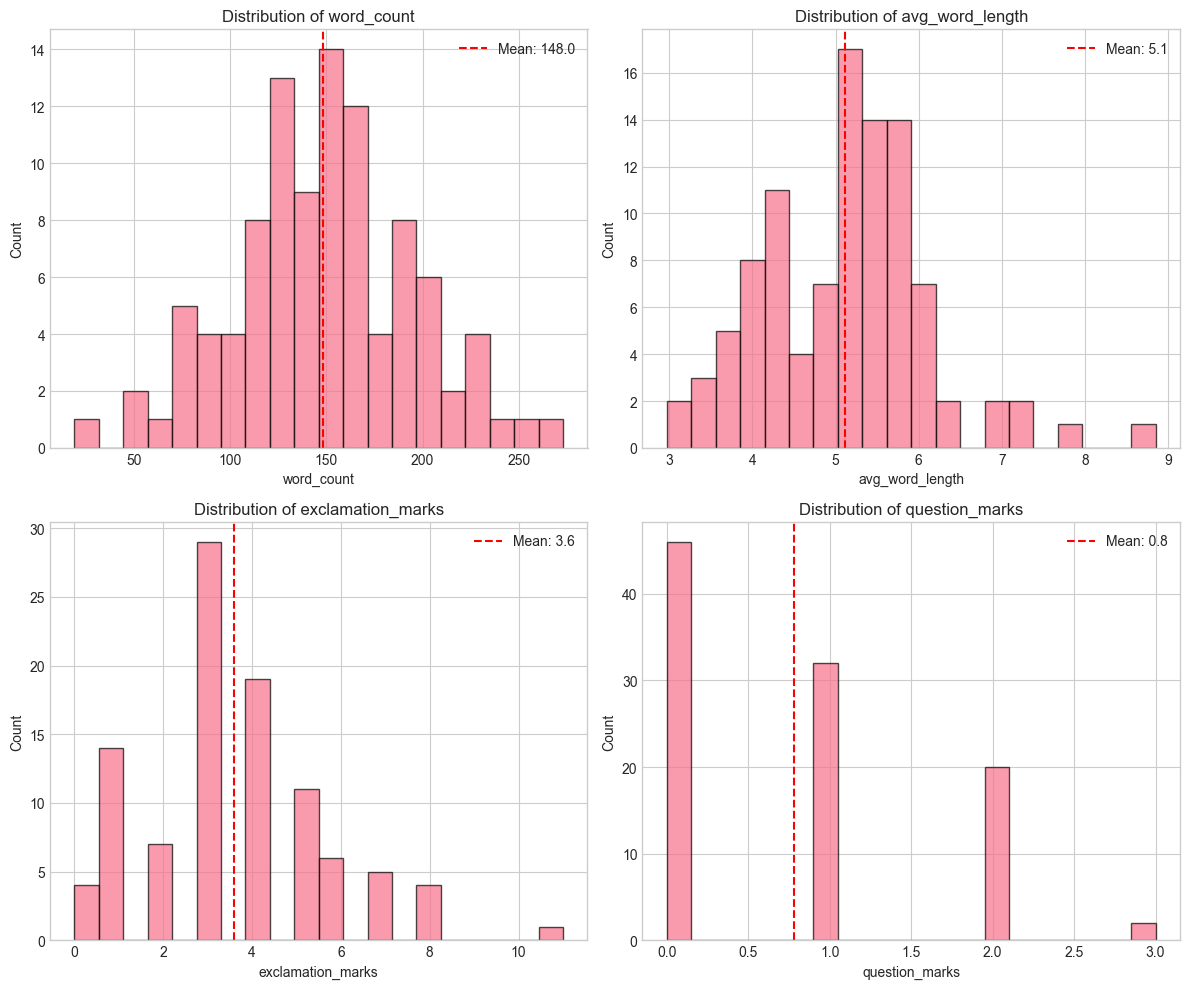

In [20]:
# Visualize the distribution of each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = ['word_count', 'avg_word_length', 'exclamation_marks', 'question_marks']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram with KDE (smooth curve)
    data[feature].hist(ax=ax, bins=20, alpha=0.7, edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {feature}')
    
    # Add mean and std info
    mean = data[feature].mean()
    std = data[feature].std()
    ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

### 🔔 The Normal Distribution

Many natural phenomena follow a **normal (Gaussian) distribution**:
- Bell-shaped curve
- Symmetric around the mean
- 68% of data within 1 std, 95% within 2 stds

ML algorithms often assume (or work better with) normally distributed data.

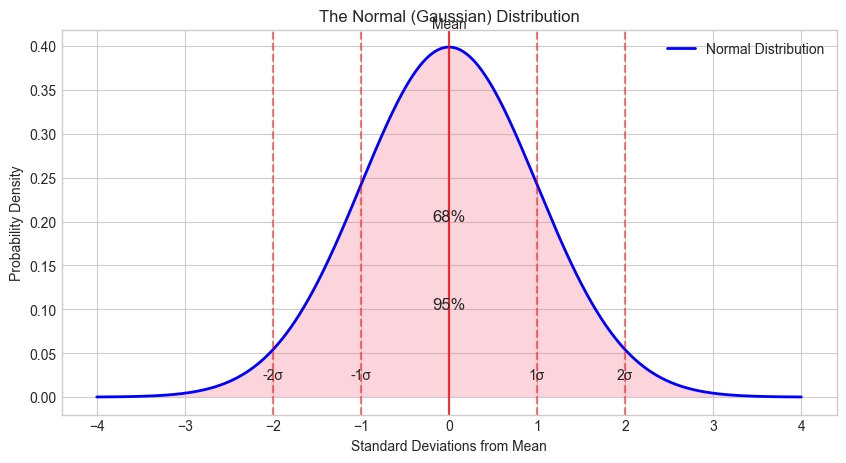

In [21]:
# Visualize the normal distribution
fig, ax = plt.subplots(figsize=(10, 5))

# Generate normal distribution
x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

ax.plot(x, y, 'b-', linewidth=2, label='Normal Distribution')
ax.fill_between(x, y, alpha=0.3)

# Mark standard deviations
for std in [-2, -1, 1, 2]:
    ax.axvline(std, color='red', linestyle='--', alpha=0.5)
    ax.text(std, 0.02, f'{std}σ', ha='center')

ax.axvline(0, color='red', linestyle='-', alpha=0.8)
ax.text(0, 0.42, 'Mean', ha='center')

# Annotations
ax.annotate('68%', xy=(0, 0.2), fontsize=12, ha='center')
ax.annotate('95%', xy=(0, 0.1), fontsize=12, ha='center')

ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Probability Density')
ax.set_title('The Normal (Gaussian) Distribution')
ax.legend()
plt.show()

## 3. Feature Relationships

Features can be **correlated** - when one goes up, another goes up (or down).

Understanding correlations helps us:
- Identify redundant features
- Find predictive patterns
- Avoid multicollinearity issues

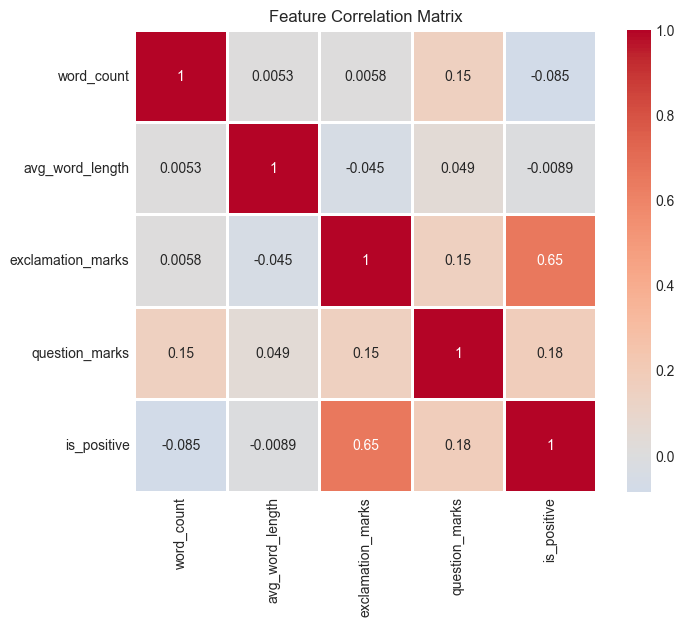


🔍 Key observations:
- exclamation_marks and is_positive correlation: 0.65
  → This makes sense! We added more ! to positive reviews.


In [22]:
# Correlation matrix
correlation = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.show()

print("\n🔍 Key observations:")
print(f"- exclamation_marks and is_positive correlation: {correlation.loc['exclamation_marks', 'is_positive']:.2f}")
print("  → This makes sense! We added more ! to positive reviews.")

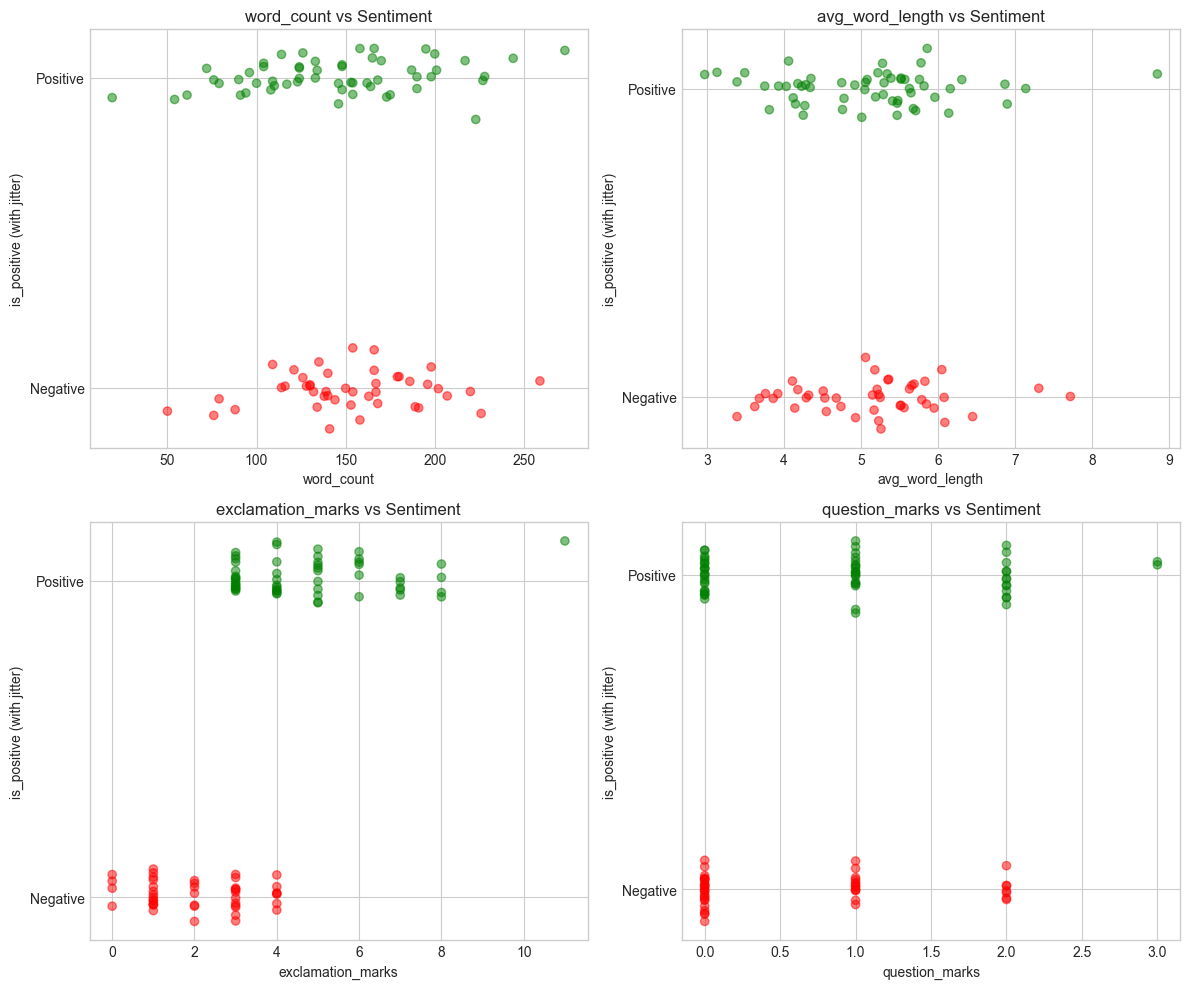

In [23]:
# Scatter plot: features vs label
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    
    # Use data directly to ensure alignment (avoids issues if cells run out of order)
    x_vals = data[feature].values
    y_vals = data['is_positive'].values
    
    # Color by label
    colors = ['red' if label == 0 else 'green' for label in y_vals]
    ax.scatter(x_vals, y_vals + np.random.normal(0, 0.05, len(y_vals)), 
               c=colors, alpha=0.5)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('is_positive (with jitter)')
    ax.set_title(f'{feature} vs Sentiment')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()

## 4. Why Normalization Matters

Features often have different scales:
- `word_count`: 50-300
- `avg_word_length`: 3-7

This can cause problems because ML algorithms may think `word_count` is more important simply because its values are bigger!

**Normalization** puts all features on the same scale.

In [24]:
# Show the scale problem
print("Original feature ranges:")
for feature in features:
    print(f"  {feature}: {X[feature].min():.1f} to {X[feature].max():.1f}")

Original feature ranges:
  word_count: 19.0 to 273.0
  avg_word_length: 3.0 to 8.8
  exclamation_marks: 0.0 to 11.0
  question_marks: 0.0 to 3.0


In [25]:
# Method 1: Min-Max Scaling (scales to 0-1)
def min_max_scale(x):
    return (x - x.min()) / (x.max() - x.min())

# Method 2: Standardization (mean=0, std=1)
def standardize(x):
    return (x - x.mean()) / x.std()

# Apply standardization
X_normalized = X.copy()
for feature in features:
    X_normalized[feature] = standardize(X[feature])

print("After standardization:")
for feature in features:
    print(f"  {feature}: mean={X_normalized[feature].mean():.2f}, std={X_normalized[feature].std():.2f}")

After standardization:
  word_count: mean=-0.00, std=1.00
  avg_word_length: mean=-0.00, std=1.00
  exclamation_marks: mean=-0.00, std=1.00
  question_marks: mean=-0.00, std=1.00


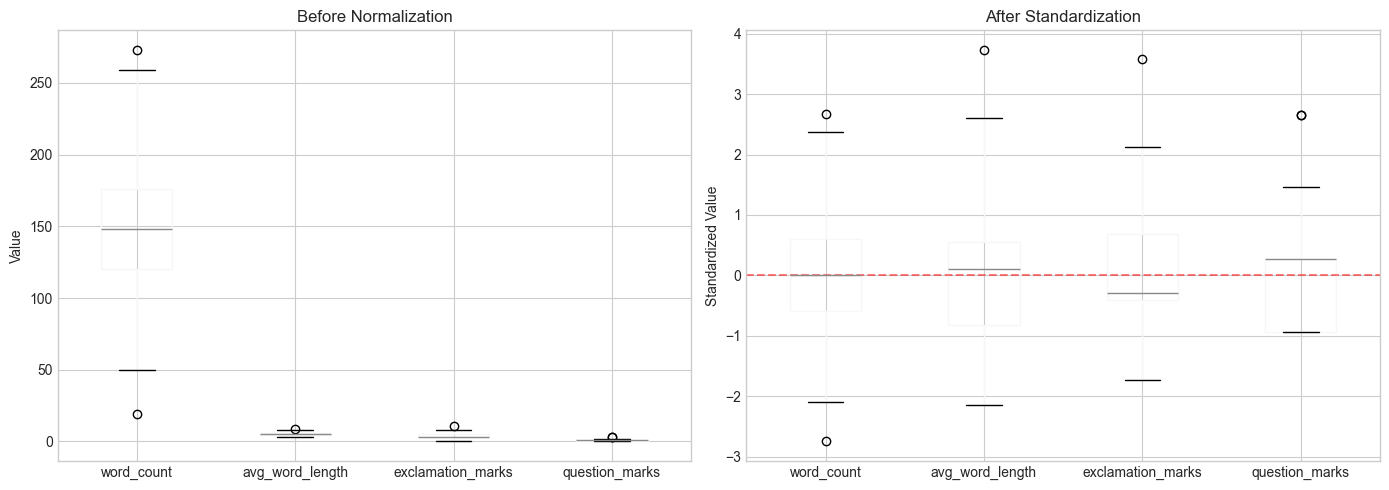


✅ Now all features are on the same scale!


In [26]:
# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before normalization
X.boxplot(ax=axes[0])
axes[0].set_title('Before Normalization')
axes[0].set_ylabel('Value')

# After normalization
X_normalized.boxplot(ax=axes[1])
axes[1].set_title('After Standardization')
axes[1].set_ylabel('Standardized Value')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n✅ Now all features are on the same scale!")

## 5. Train/Test Split: The Cardinal Rule

**Never evaluate your model on data it has seen before!**

It's like testing students with the exact questions they practiced - you won't know if they really learned.

We split data into:
- **Training set**: Used to learn patterns (typically 70-80%)
- **Test set**: Used to evaluate (held out, never touched during training)

In [ ]:
# Manual train/test split
def train_test_split(X, y, test_size=0.2, random_state=None):
    """Split data into training and test sets."""
    if random_state:
        np.random.seed(random_state)
    
    n_samples = len(X)
    n_test = int(n_samples * test_size)
    
    # Shuffle indices
    indices = np.random.permutation(n_samples)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    if isinstance(X, pd.DataFrame):
        X_train = X.iloc[train_indices]
        X_test = X.iloc[test_indices]
    else:
        X_train = X[train_indices]
        X_test = X[test_indices]
    
    if isinstance(y, pd.Series):
        y_train = y.iloc[train_indices]
        y_test = y.iloc[test_indices]
    else:
        y_train = y[train_indices]
        y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

# Split our data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Count labels (works with both numpy arrays and pandas Series)
train_neg, train_pos = sum(y_train == 0), sum(y_train == 1)
test_neg, test_pos = sum(y_test == 0), sum(y_test == 1)

print(f"\nLabel distribution in training: {{0: {train_neg}, 1: {train_pos}}}")
print(f"Label distribution in test: {{0: {test_neg}, 1: {test_pos}}}")

In [ ]:
# Visualize the split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart of split
axes[0].pie([len(X_train), len(X_test)], 
            labels=['Training (80%)', 'Test (20%)'],
            autopct='%1.0f%%',
            colors=['skyblue', 'lightcoral'])
axes[0].set_title('Data Split')

# Bar chart of label distribution
x = np.arange(2)
width = 0.35

train_counts = [sum(y_train == 0), sum(y_train == 1)]
test_counts = [sum(y_test == 0), sum(y_test == 1)]

axes[1].bar(x - width/2, train_counts, width, label='Training', color='skyblue')
axes[1].bar(x + width/2, test_counts, width, label='Test', color='lightcoral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Negative', 'Positive'])
axes[1].set_ylabel('Count')
axes[1].set_title('Label Distribution by Set')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. NLP Data: Text as Features

In NLP, our raw data is text. We need to convert it to numbers!

Common approaches:
1. **Count-based**: Count word occurrences
2. **TF-IDF**: Weight words by importance
3. **Embeddings**: Dense vector representations (Module 5)

Let's see count-based features in action:

In [ ]:
# Sample text data
reviews = [
    "This movie was amazing! I loved it!",
    "Terrible film. Waste of time.",
    "Great acting and wonderful story!",
    "Boring and predictable. Not recommended.",
    "Absolutely fantastic! A must see!",
]
labels = [1, 0, 1, 0, 1]  # 1 = positive, 0 = negative

for i, (review, label) in enumerate(zip(reviews, labels)):
    sentiment = "Positive" if label == 1 else "Negative"
    print(f"{sentiment}: \"{review}\"")

In [ ]:
# Bag of Words: count each word
import re
from collections import Counter

def simple_tokenize(text):
    """Convert text to lowercase words."""
    return re.findall(r'\b[a-z]+\b', text.lower())

def create_vocabulary(texts):
    """Create a vocabulary from all texts."""
    all_words = []
    for text in texts:
        all_words.extend(simple_tokenize(text))
    return sorted(set(all_words))

def text_to_bow(text, vocab):
    """Convert text to bag-of-words vector."""
    words = simple_tokenize(text)
    word_counts = Counter(words)
    return np.array([word_counts.get(word, 0) for word in vocab])

# Create vocabulary and feature matrix
vocab = create_vocabulary(reviews)
print(f"Vocabulary ({len(vocab)} words): {vocab}")

In [ ]:
# Create feature matrix
X_text = np.array([text_to_bow(review, vocab) for review in reviews])

# Create DataFrame for visualization
bow_df = pd.DataFrame(X_text, columns=vocab)
bow_df['LABEL'] = labels
bow_df['REVIEW'] = [r[:30] + '...' if len(r) > 30 else r for r in reviews]

# Display
print("Bag of Words representation:")
print(f"Shape: {X_text.shape} (5 reviews × {len(vocab)} words)")
bow_df

In [ ]:
# Visualize the bag-of-words matrix
plt.figure(figsize=(14, 5))

# Heatmap of word counts
sns.heatmap(X_text, 
            xticklabels=vocab, 
            yticklabels=[f"Review {i+1}" for i in range(len(reviews))],
            cmap='YlOrRd', 
            annot=True, 
            fmt='d',
            cbar_kws={'label': 'Word Count'})
plt.title('Bag of Words: Each Review as Word Counts')
plt.xlabel('Words in Vocabulary')
plt.ylabel('Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n🔍 Notice: Each review is now a vector of numbers!")
print("   These vectors can be fed into ML algorithms.")

### The Limitation of Bag-of-Words

Notice that we lose:
- **Word order**: "not good" = "good not" (same counts!)
- **Context**: "I loved it" vs "I didn't love it" might look similar
- **Synonyms**: "great" and "amazing" are separate features

We'll address these limitations in later modules with:
- **Embeddings** (Module 5): Capture word meaning
- **Sequence models** (Module 6): Capture word order

## 📝 Check Your Understanding

1. What's the difference between a feature and a label?
2. Why is normalization important?
3. Why do we split data into train and test sets?
4. What information does bag-of-words lose?
5. If two features are highly correlated (0.95), what does that suggest?

In [ ]:
# Your turn! Exercises:

# Exercise 1: Create a new review and convert it to bag-of-words
new_review = "I really enjoyed this wonderful movie!"  # Try your own!
# Your code here

# Exercise 2: What's the most common word in positive reviews?
# Hint: Sum the columns where label == 1
# Your code here

# Exercise 3: Normalize the word_count column using min-max scaling
# Your code here

## 🎯 Summary

You learned:
- **Samples** are data points, **features** are measurements, **labels** are what we predict
- **Distributions** show how values are spread out
- **Correlation** measures how features relate
- **Normalization** puts features on the same scale
- **Train/test split** prevents overfitting to training data
- **Bag-of-words** converts text to numbers (but loses order)

**Next up**: Your first prediction with linear regression! →